In [1]:
"""
Этап 1. Проведите исследовательский анализ (EDA)
1. Загрузите датасет и визуализируйте часть данных. Изучите то, с чем предстоит работать
2. Сформируйте видение:
как вы будете решать задачу,
какие подходы к обогащению/аугментации данных примените и почему,
на какие метрики будете ориентироваться при обучении.
3. Объедините таблицы dish.csv и ingredients.csv.
В колонке ingredients таблицы dish.csv хранятся технические идентификаторы вида ingr_0000000122 — модель не извлечёт из них никакой информации о блюде.  Замените идентификаторы на реальные названия продуктов из ingredients.csv (колонка ingr), чтобы текстовая компонента модели получала осмысленный вход.
Пример: "ingr_0000000122;ingr_0000000026" => "salmon, zucchini".
"""

import pandas as pd

# 1. Загрузите датасет и визуализируйте часть данных. Изучите то, с чем предстоит работать
dish_df = pd.read_csv("data/dish.csv")
print("Dish.csv")
print("Количество элементов датасета:", len(dish_df))
print("Количество элементов тестового датасета:", (dish_df["split"] == "test").sum())
print("Количество элементов тренировочного датасета:", (dish_df["split"] == "train").sum())
print(dish_df.loc[:5])
print("")

ing_df = pd.read_csv("data/ingredients.csv")
print("Ingredients.csv")
print("Количество ингридиентов:", len(ing_df))
print(ing_df.loc[:5])


Dish.csv
Количество элементов датасета: 3262
Количество элементов тестового датасета: 507
Количество элементов тренировочного датасета: 2755
           dish_id  total_calories  total_mass  \
0  dish_1561662216      300.794281       193.0   
1  dish_1561662054      419.438782       292.0   
2  dish_1562008979      382.936646       290.0   
3  dish_1560455030       20.590000       103.0   
4  dish_1558372433       74.360001       143.0   
5  dish_1565640549       45.482903       139.0   

                                         ingredients  split  
0  ingr_0000000508;ingr_0000000122;ingr_000000002...   test  
1  ingr_0000000312;ingr_0000000026;ingr_000000002...  train  
2  ingr_0000000448;ingr_0000000520;ingr_000000046...   test  
3    ingr_0000000471;ingr_0000000031;ingr_0000000347  train  
4                                    ingr_0000000453  train  
5  ingr_0000000032;ingr_0000000523;ingr_000000016...  train  

Ingredients.csv
Количество ингридиентов: 555
   id            ingr
0   1 

419.438782
382.936646
20.59
74.360001
45.482903


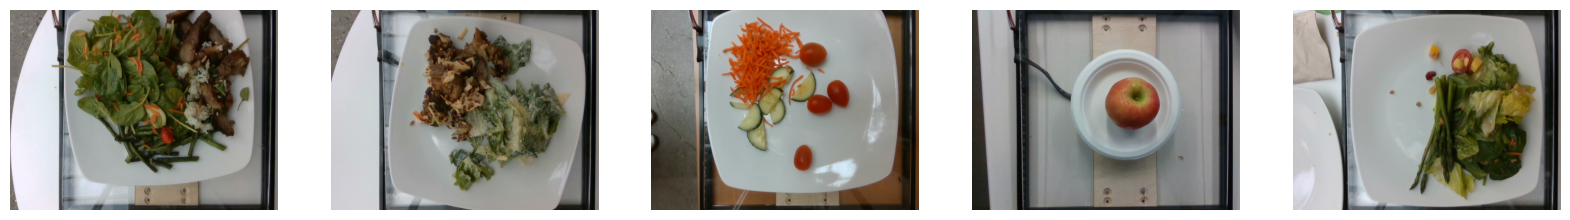

In [2]:
image_path = "data/images"

# Вывелем примеры пары изображений
from PIL import Image
from matplotlib import pyplot as plt

# Визуализация датасета до трансформаций
fig = plt.figure(figsize=(20,5))
for index in range (1, 6):
    image = f"{image_path}/{dish_df.loc[index, 'dish_id']}/rgb.png"
    label = dish_df.loc[index, "total_calories"]
    img = Image.open(image)
    print(label)
    plt.subplot(1, 5, index)
    plt.imshow(img)
    plt.axis('off')

In [3]:
"""
Сформируйте видение:
как вы будете решать задачу,
какие подходы к обогащению/аугментации данных примените и почему,
на какие метрики будете ориентироваться при обучении.
"""

msg = "Так как мы имеем дело не тлько с картинками, а с набором данных где есть и картинки и текст, нам понадобиться мультимодальная архитектура.\n" + \
"Для картинок мы можем использовать tf_efficientnet_b0. Текстовая компонента модели будет обрабатывать список ингридиентов.\n" + \
"Обогащение и аугментация данных:\n" + \
"Для текста перестановка ингридииентов местами не должно влиять на результат. Для каждого примера ингридиенты будут пермешиваться\n" + \
"Текст будет приведен к нижнему регистру\n" + \
"Визуальная аугментация: Так как у нас всего 2755 тренировочных ихображений нужна аугментация, илии можель переобучится.\n" + \
"Можно применить масштабирование, цветовый искажения, повороты и отражения.\n" + \
"Масса может быть передана в нормализованном виде от 0 до 1\n" + \
""

print(msg)

Так как мы имеем дело не тлько с картинками, а с набором данных где есть и картинки и текст, нам понадобиться мультимодальная архитектура.
Для картинок мы можем использовать tf_efficientnet_b0. Текстовая компонента модели будет обрабатывать список ингридиентов.
Обогащение и аугментация данных:
Для текста перестановка ингридииентов местами не должно влиять на результат. Для каждого примера ингридиенты будут пермешиваться
Текст будет приведен к нижнему регистру
Визуальная аугментация: Так как у нас всего 2755 тренировочных ихображений нужна аугментация, илии можель переобучится.
Можно применить масштабирование, цветовый искажения, повороты и отражения.
Масса может быть передана в нормализованном виде от 0 до 1



In [4]:
for i in range(len(dish_df)):
    ingredients = dish_df.loc[i, "ingredients"].split(";")
    ingredients_str = []
    for ing in ingredients:
        index = int(ing[-3:])
        val = ing_df.loc[index-1, "ingr"]
        ingredients_str.append(val)
    dish_df.loc[i, "ingredients"] = ";".join(ingredients_str)



In [5]:

print(dish_df.loc[:5])

           dish_id  total_calories  total_mass  \
0  dish_1561662216      300.794281       193.0   
1  dish_1561662054      419.438782       292.0   
2  dish_1562008979      382.936646       290.0   
3  dish_1560455030       20.590000       103.0   
4  dish_1558372433       74.360001       143.0   
5  dish_1565640549       45.482903       139.0   

                                         ingredients  split  
0  soy sauce;garlic;white rice;parsley;onions;bro...   test  
1  pepper;white rice;mixed greens;garlic;soy sauc...  train  
2  jalapenos;lemon juice;pork;wheat berry;cabbage...   test  
3             cherry tomatoes;cucumbers;baby carrots  train  
4                                         deprecated  train  
5  tomatoes;cilantro;olive oil;mustard greens;lem...  train  


In [6]:
"""
Этап 2. Реализуйте пайплайн обучения
Для корректной сборки монолитных py-файлов убедитесь, что в начале каждого файла собраны все нужные импорты.

"""

from utils_dl import train
import torch

class Config:
    SEED = 42
    IMG_DIR = "data/images"
    # IMAGE_MODEL_NAME = "efficientnet_b0"
    # TEXT_MODEL_NAME = "distilbert-base-uncased" # Хорошо справляется с опечатками
    TEXT_MODEL_NAME = "bert-base-uncased"
    IMAGE_MODEL_NAME = "resnet50"

    TEXT_MODEL_UNFREEZE = "encoder.layer.11|pooler"  
    IMAGE_MODEL_UNFREEZE = "layer.3|layer.4"
    PROJ_DIM = 128
    BATCH_SIZE = 4
    EPOCHS = 15
    IMAGE_LR = 5e-4
    TEXT_LR = 1e-5
    CLASSIFIER_LR = 1e-3

    HIDDEN_DIM = 128
    SAVE_PATH = "best_model.pth"

# Запуск
train_df = dish_df[dish_df["split"] == "train"].copy()
train_df.reset_index(drop=True, inplace=True)
val_df = dish_df[dish_df["split"] == "test"].copy()
val_df.reset_index(drop=True, inplace=True  )




/home/ubuntu/sprint4/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [7]:
train_df.loc[:100]

,dish_id,total_calories,total_mass,ingredients,split
0,dish_1561662054,419.438782,292.0,pepper;white rice;mixed greens;garlic;soy sauc...,train
1,dish_1560455030,20.590000,103.0,cherry tomatoes;cucumbers;baby carrots,train
2,dish_1558372433,74.360001,143.0,deprecated,train
3,dish_1565640549,45.482903,139.0,tomatoes;cilantro;olive oil;mustard greens;lem...,train
4,dish_1563207364,309.269989,271.0,scrambled eggs;yam;grapes;egg whites;olive oil...,train
...,...,...,...,...,...
96,dish_1565725047,77.659996,110.0,carrot;olives,train
97,dish_1559841163,357.043518,335.0,blackberries;scrambled eggs;yam;sweet potato;c...,train
98,dish_1563568338,631.706665,371.0,salt;garlic;olive oil;kale;onions;wheat berry;...,train
99,dish_1563468299,210.350006,385.0,cottage cheese;pineapple;watermelon;berries,train


In [8]:
device = "cuda" if torch.cuda.is_available() else "cpu"
model = train(Config(), device,  train_df, val_df)

Разморожен слой: encoder.layer.11.attention.self.query.weight
Разморожен слой: encoder.layer.11.attention.self.query.bias
Разморожен слой: encoder.layer.11.attention.self.key.weight
Разморожен слой: encoder.layer.11.attention.self.key.bias
Разморожен слой: encoder.layer.11.attention.self.value.weight
Разморожен слой: encoder.layer.11.attention.self.value.bias
Разморожен слой: encoder.layer.11.attention.output.dense.weight
Разморожен слой: encoder.layer.11.attention.output.dense.bias
Разморожен слой: encoder.layer.11.attention.output.LayerNorm.weight
Разморожен слой: encoder.layer.11.attention.output.LayerNorm.bias
Разморожен слой: encoder.layer.11.intermediate.dense.weight
Разморожен слой: encoder.layer.11.intermediate.dense.bias
Разморожен слой: encoder.layer.11.output.dense.weight
Разморожен слой: encoder.layer.11.output.dense.bias
Разморожен слой: encoder.layer.11.output.LayerNorm.weight
Разморожен слой: encoder.layer.11.output.LayerNorm.bias
Разморожен слой: pooler.dense.weight
Раз

In [9]:
"""
Этап 3. Модель обучена и сохранена в best_model
"""


'\nЭтап 3. Модель обучена и сохранена в best_model\n'

In [17]:
""""
Этап 4. Валидация качества
"""
from utils_dl import MultimodalModel, validate , collate_fn, DataLoader, partial, torchmetrics, AutoTokenizer
from dataset import MultimodalDataset
import albumentations as A

config = Config()

model = MultimodalModel(config)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
state_dict = torch.load("best_model.pth", map_location=device)
model.load_state_dict(state_dict)
model.to(device)
model.eval()

print("Модель загружена и готова к работе")

tokenizer = AutoTokenizer.from_pretrained(config.TEXT_MODEL_NAME)


val_dataset = MultimodalDataset(config, A.Compose([]), val_df)
val_loader = DataLoader(val_dataset,
    batch_size=config.BATCH_SIZE,
    shuffle=False,
    collate_fn=partial(collate_fn, tokenizer=tokenizer))


# metric = torchmetrics.MeanAbsoluteError().to(device)
# res = validate(model, val_loader, device, metric)

import torch
import matplotlib.pyplot as plt
from PIL import Image

def analyze_errors(model, val_loader, device, original_df):
    model.eval()
    errors = []
    metric = torchmetrics.MeanAbsoluteError().to(device)
    with torch.no_grad():
        for i, batch in enumerate(val_loader):
            # Получаем предсказания плотности и пересчитываем в калории
            preds_density = model(
                batch['input_ids'].to(device), 
                batch['attention_mask'].to(device),
                batch['image'].to(device)
            ).view(-1)
            
            # Предсказание: плотность * масса
            pred_calories = preds_density * batch['total_mass'].to(device)
            real_calories = batch['total_calories'].to(device)
            
            # Считаем разницу
            abs_error = torch.abs(pred_calories - real_calories)
            metric.update(pred_calories*batch['total_mass'].to(device), batch['total_calories'].to(device))
            
            # Сохраняем информацию об ошибках для анализа
            for j in range(len(batch['label'])):
                errors.append({
                    'dish_id': original_df.iloc[i * val_loader.batch_size + j]['dish_id'],
                    'ingredients': original_df.iloc[i * val_loader.batch_size + j]['ingredients'],
                    'real': real_calories[j].item(),
                    'pred': pred_calories[j].item(),
                    'error': abs_error[j].item()
                })

    # Сортируем по убыванию ошибки и берем топ-5
    top_errors = sorted(errors, key=lambda x: x['error'], reverse=True)[:5]
    
    # Визуализация
    for item in top_errors:
        print(f"\n{'='*50}")
        print(f"ID блюда: {item['dish_id']}")
        print(f"Ингредиенты: {item['ingredients'].replace(';', ', ')}")
        print(f"Реальные калории: {item['real']:.1f}")
        print(f"Предсказание: {item['pred']:.1f}")
        print(f"Ошибка (MAE): {item['error']:.1f}")
        
        # Загрузка и показ фото
        img_path = f"data/images/{item['dish_id']}/rgb.jpg"
        try:
            img = Image.open(img_path)
            plt.figure(figsize=(6, 4))
            plt.imshow(img)
            plt.title(f"Error: {item['error']:.1f} kcal")
            plt.axis('off')
            plt.show()
        except FileNotFoundError:
            print("Фото не найдено.")

# Запуск
analyze_errors(model, val_loader, device, val_df)

Модель загружена и готова к работе


TypeError: expected Tensor as element 0 in argument 0, but got numpy.ndarray